# Bootstrap và K-Fold Cross-Validation

Hai kỹ thuật, hai mục tiêu khác nhau:

| Phần | Kỹ thuật | Việc cần làm |
|---|---|---|
| 1 | Bootstrap | Chia 80:20, ước lượng **khoảng tin cậy cho Recall lớp có bệnh** |
| 2 | K-Fold | **Stratified K-Fold với k = 5** |

Mô hình dùng chung: Logistic Regression + SMOTE. Dữ liệu và các quyết định chọn biến kế thừa từ `01_eda.ipynb`.


In [39]:
# ---- Nạp dữ liệu và dựng quy trình huấn luyện ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)

# Target: 1 = có bệnh, 0 = không bệnh
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({2: 0, 1: 1})

# log1p cho 5 biến lệch phải nặng (lý do trình bày ở 01_eda.ipynb)
for c in ["Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
          "Alamine_Aminotransferase", "Aspartate_Aminotransferase"]:
    df[c] = np.log1p(df[c])

# Bỏ 3 biến: Direct_Bilirubin (trùng thông tin với Total_Bilirubin),
# Gender và Total_Protiens (không có quan hệ với target - kiểm định ở 01_eda.ipynb)
df_model = df.drop(columns=['Direct_Bilirubin', 'Gender', 'Total_Protiens'])

X = df_model.drop(columns=['Liver cirrhosis']).to_numpy()
y = df_model['Liver cirrhosis'].to_numpy()


def fit_predict(X_tr, y_tr, X_te):
    """Huấn luyện trên (X_tr, y_tr) rồi dự đoán cho X_te.

    Ba bước impute / scale / SMOTE đều HỌC THAM SỐ từ dữ liệu, nên phải đặt
    bên trong hàm này để chúng chỉ nhìn thấy tập huấn luyện. Nếu chạy chúng
    trên toàn bộ dữ liệu trước khi chia thì tập kiểm tra bị rò rỉ thông tin.
    """
    imp = SimpleImputer(strategy='median').fit(X_tr)       # điền khuyết bằng median của train
    X_tr, X_te = imp.transform(X_tr), imp.transform(X_te)

    sc = StandardScaler().fit(X_tr)                        # chuẩn hoá theo mean/std của train
    X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

    X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)   # cân bằng lớp, chỉ trên train

    model = LogisticRegression(max_iter=1000, random_state=42).fit(X_res, y_res)
    return model.predict(X_te)


print(f"Dữ liệu: {len(y)} dòng, {X.shape[1]} biến")
print(f"Phân bố target: {np.bincount(y)[1]} có bệnh / {np.bincount(y)[0]} không bệnh")

Dữ liệu: 583 dòng, 7 biến
Phân bố target: 416 có bệnh / 167 không bệnh


## Phần 1. Bootstrap: khoảng tin cậy cho Recall

Recall lớp có bệnh chỉ là **một con số tính từ 117 bệnh nhân trong tập test**. Nếu lấy một nhóm 117 người khác, con số đó sẽ khác. Bootstrap ước lượng mức dao động ấy: rút lại tập test có hoàn lại 10000 lần, tính recall mỗi lần, rồi cắt bỏ 5% ở mỗi đuôi để lấy **khoảng tin cậy 90%**.

Ưu điểm: không cần giả định phân phối nào, và dùng được cho cả những chỉ số không có công thức sai số chuẩn dạng đóng.


In [40]:
# ---- PHẦN 1: Bootstrap cho khoảng tin cậy của Recall lớp "có bệnh" ----

# Bước 1: chia 80:20 phân tầng (stratify giữ nguyên tỉ lệ 71/29 ở cả hai tập)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Bước 2: huấn luyện một lần trên tập train, dự đoán cho tập test
y_pred = fit_predict(X_train, y_train, X_test)

# Recall lớp 1 = trong số ca thực sự có bệnh, mô hình bắt được bao nhiêu phần trăm
recall_point = recall_score(y_test, y_pred, pos_label=1)

# Bước 3: bootstrap - rút lại tập test CÓ HOÀN LẠI, cùng cỡ mẫu, lặp B lần.
# Mỗi lần rút mô phỏng "nếu ta lấy được một nhóm 117 bệnh nhân khác thì recall sẽ là bao nhiêu".
#
# Chọn B thế nào: hai cận của khoảng là các PHÂN VỊ ước lượng từ B giá trị, nên mỗi
# đuôi phải có đủ số giá trị thì cận mới ổn định. Mức tin cậy càng cao thì đuôi càng
# mỏng và càng cần B lớn:
#   CONF = 0.90 -> đuôi 5%   -> B = 10000 cho ~500 giá trị mỗi đuôi (rất dư, B=2000 đã đủ)
#   CONF = 0.99 -> đuôi 0.5% -> B = 10000 chỉ còn ~50 giá trị mỗi đuôi (lúc đó mới thực sự cần)
CONF = 0.9        # mức tin cậy - đổi mỗi số này là đủ
B = 10000
rng = np.random.default_rng(42)
n_test = len(y_test)

recalls = []
for _ in range(B):
    idx = rng.integers(0, n_test, n_test)      # chỉ số rút có hoàn lại
    if y_test[idx].sum() == 0:                 # bỏ mẫu không có ca bệnh nào -> recall vô nghĩa
        continue
    recalls.append(recall_score(y_test[idx], y_pred[idx], pos_label=1))

recalls = np.array(recalls)

# Bước 4: khoảng tin cậy theo phương pháp percentile.
# Cắt bỏ (1-CONF)/2 ở MỖI đuôi: mức 90% -> cắt 5% mỗi bên -> lấy phân vị 5% và 95%
tail = (1 - CONF) / 2 * 100
ci_low, ci_high = np.percentile(recalls, [tail, 100 - tail])

print(f"Tập test: {n_test} bệnh nhân ({int(y_test.sum())} ca có bệnh)")
print(f"Trung bình recall qua {len(recalls)} mẫu bootstrap = {recalls.mean():.3f}")
print(f"Khoảng tin cậy {CONF:.0%}    = [{ci_low:.3f}, {ci_high:.3f}]"
      f"   (phân vị {tail:g}% và {100 - tail:g}%)")
print(f"Sai số chuẩn          = {recalls.std(ddof=1):.3f}")

Tập test: 117 bệnh nhân (83 ca có bệnh)
Trung bình recall qua 10000 mẫu bootstrap = 0.723
Khoảng tin cậy 90%    = [0.641, 0.802]   (phân vị 5% và 95%)
Sai số chuẩn          = 0.049


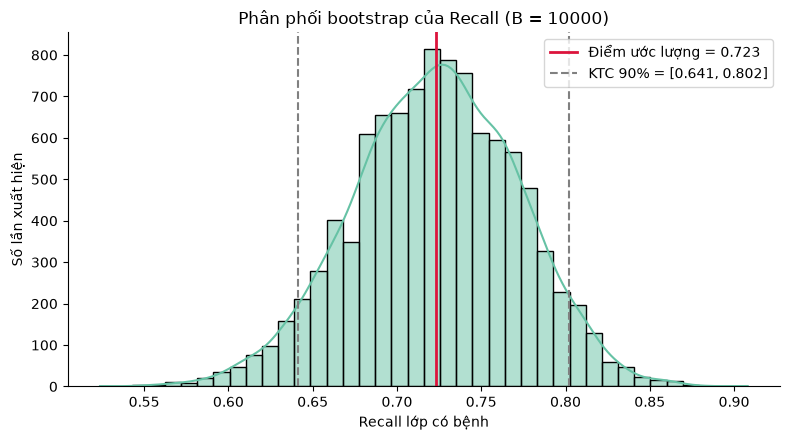

In [41]:
# ---- Biểu đồ phân phối bootstrap của Recall ----
plt.figure(figsize=(8, 4.5))
sns.histplot(recalls, bins=40, kde=True, color='#66c2a5')

plt.axvline(recall_point, color='crimson', linewidth=2, label=f'Điểm ước lượng = {recall_point:.3f}')
plt.axvline(ci_low, color='gray', linestyle='--', linewidth=1.5,
            label=f'KTC {CONF:.0%} = [{ci_low:.3f}, {ci_high:.3f}]')
plt.axvline(ci_high, color='gray', linestyle='--', linewidth=1.5)

plt.xlabel('Recall lớp có bệnh')
plt.ylabel('Số lần xuất hiện')
plt.title(f'Phân phối bootstrap của Recall (B = {len(recalls)})')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Phần 2. Stratified K-Fold (k = 5)

Chia dữ liệu thành 5 phần bằng nhau, lần lượt lấy một phần làm tập kiểm tra và huấn luyện trên 4 phần còn lại. Mỗi quan sát được dự đoán đúng một lần, và mô hình được đánh giá trên 5 tập kiểm tra khác nhau.

**Vì sao Stratified:** mỗi fold giữ nguyên tỉ lệ 71/29 của target. Bắt buộc với dữ liệu mất cân bằng — K-Fold thường có thể tạo ra fold lệch hẳn về một lớp, khiến recall của fold đó vô nghĩa.

**Vì sao k = 5:** mỗi fold kiểm tra đúng 20% dữ liệu, trùng với tỉ lệ 80:20 đã dùng ở Phần 1. Hai phần vì vậy cùng đánh giá mô hình huấn luyện trên ~466 mẫu nên đọc chung được.


In [ ]:
# ---- PHẦN 2: Stratified K-Fold với k = 5 ----

# StratifiedKFold: mỗi fold giữ nguyên tỉ lệ 71/29 của target.
# shuffle=True để xáo dữ liệu trước khi chia (dữ liệu gốc có thể đã được sắp xếp sẵn).
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

rows = []
for i, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    # Huấn luyện trên 4 fold, chấm điểm trên fold còn lại.
    # fit_predict đã gói impute/scale/SMOTE bên trong nên không có rò rỉ dữ liệu.
    pred = fit_predict(X[train_idx], y[train_idx], X[test_idx])

    rows.append({
        'Fold': i,
        'Cỡ train': len(train_idx),
        'Cỡ test': len(test_idx),
        'Accuracy': accuracy_score(y[test_idx], pred),
        'Recall': recall_score(y[test_idx], pred, pos_label=1),   # recall lớp có bệnh
        'Macro F1': f1_score(y[test_idx], pred, average='macro'),
    })

kfold_df = pd.DataFrame(rows).set_index('Fold')
display(kfold_df.round(4))

# Báo cáo dạng mean ± std thay vì một con số đơn lẻ.
# std ở đây cho biết kết quả dao động bao nhiêu khi đổi sang tập kiểm tra khác.
print(f"Kết quả {K}-Fold (mean ± std giữa các fold):")
for m in ['Accuracy', 'Recall', 'Macro F1']:
    print(f"  {m:<9} = {kfold_df[m].mean():.3f} ± {kfold_df[m].std(ddof=1):.3f}")